In [1]:
# Crime Data Analysis Project
# Week 1: Data Understanding


# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/2024-10-west-midlands-street.csv")

# Display the first five rows
print(df.head())

# Display the dataset shape
print(df.shape)

# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display dataset information
print(df.info())

# Display summary statistics for numerical columns
print(df.describe())

                                            Crime ID    Month  \
0  78700957f73cb56ff85b2c0a0065e24f0c088007908ecb...  2024-10   
1  9aa709ac5ad9178bf968a4cc988fac8fec6f7756c0d353...  2024-10   
2  10148e5eed4cf8ab0e6f4a536b1600a5731da1388cb2ef...  2024-10   
3  8e6513aeec679688c5d820f42428966d9af4e47a15e842...  2024-10   
4  000fef2cb04f514e6dcbf96fc4bafd3998722839bef2bd...  2024-10   

            Reported by          Falls within  Longitude   Latitude  \
0  West Midlands Police  West Midlands Police  -1.847123  52.593864   
1  West Midlands Police  West Midlands Police  -1.844026  52.597339   
2  West Midlands Police  West Midlands Police  -1.840582  52.598279   
3  West Midlands Police  West Midlands Police  -1.846312  52.593702   
4  West Midlands Police  West Midlands Police  -1.846312  52.593702   

                       Location  LSOA code        LSOA name  \
0        On or near Bramble Way  E01009417  Birmingham 001A   
1     On or near Weymouth Drive  E01009418  Birmingham 0

In [2]:
# Check the number of missing values in each column
df.isnull().sum()

Crime ID                  2568
Month                        0
Reported by                  0
Falls within                 0
Longitude                    0
Latitude                     0
Location                     0
LSOA code                    0
LSOA name                    0
Crime type                   0
Last outcome category     2568
Context                  29074
dtype: int64

In [3]:
# Remove the Context column because it contains only missing values
df = df.drop(columns=["Context"])

In [4]:
# Replace missing values with "Unknown"
df["Last outcome category"] = df["Last outcome category"].fillna("Unknown")
df["Last outcome category"].isnull().sum()

np.int64(0)

In [5]:
# Count missing Crime IDs
df["Crime ID"].isnull().sum()

np.int64(2568)

In [6]:
# Count duplicate rows
df.duplicated().sum() #np.int64(630)
# Remove duplicate records
df = df.drop_duplicates()
df.duplicated().sum()




np.int64(0)

In [7]:
#Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28444 entries, 0 to 29073
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               26506 non-null  object 
 1   Month                  28444 non-null  object 
 2   Reported by            28444 non-null  object 
 3   Falls within           28444 non-null  object 
 4   Longitude              28444 non-null  float64
 5   Latitude               28444 non-null  float64
 6   Location               28444 non-null  object 
 7   LSOA code              28444 non-null  object 
 8   LSOA name              28444 non-null  object 
 9   Crime type             28444 non-null  object 
 10  Last outcome category  28444 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.6+ MB


In [8]:
# Convert Month to datetime
df["Month"] = pd.to_datetime(df["Month"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28444 entries, 0 to 29073
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Crime ID               26506 non-null  object        
 1   Month                  28444 non-null  datetime64[ns]
 2   Reported by            28444 non-null  object        
 3   Falls within           28444 non-null  object        
 4   Longitude              28444 non-null  float64       
 5   Latitude               28444 non-null  float64       
 6   Location               28444 non-null  object        
 7   LSOA code              28444 non-null  object        
 8   LSOA name              28444 non-null  object        
 9   Crime type             28444 non-null  object        
 10  Last outcome category  28444 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 2.6+ MB


In [9]:
df = df.rename(columns={
    "Reported by":"Reported_By",
    "Falls within":"Falls_Within",
    "Crime type":"Crime_Type",
    "Last outcome category":"Last_Outcome_Category",
    "LSOA code":"LSOA_Code",
    "LSOA name":"LSOA_Name",
    "Crime ID":"Crime_ID"
})
df.columns

Index(['Crime_ID', 'Month', 'Reported_By', 'Falls_Within', 'Longitude',
       'Latitude', 'Location', 'LSOA_Code', 'LSOA_Name', 'Crime_Type',
       'Last_Outcome_Category'],
      dtype='object')

In [10]:
# Check longitude values
df["Longitude"].describe()
# Check latitude values
df["Latitude"].describe()
# Check crime categories
df["Crime_Type"].unique()

array(['Burglary', 'Violence and sexual offences',
       'Anti-social behaviour', 'Criminal damage and arson',
       'Other theft', 'Public order', 'Vehicle crime', 'Shoplifting',
       'Robbery', 'Other crime', 'Possession of weapons', 'Drugs',
       'Theft from the person', 'Bicycle theft'], dtype=object)

In [11]:
# Create a Year column from the Month column
df["Year"] = df["Month"].dt.year


In [12]:
#Handle Outliers: Longitude
Q1 = df["Longitude"].quantile(0.25)
Q3 = df["Longitude"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers  = df[(df["Longitude"] < lower) | (df["Longitude"] > upper)]

print("Number of longitude outliers:", len(outliers))

Number of longitude outliers: 2947


In [13]:
#Handle Outliers: Latitude
Q1 = df["Latitude"].quantile(0.25)
Q3 = df["Latitude"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers  = df[(df["Latitude"] < lower) | (df["Latitude"] > upper)]

print("Number of latitude outliers:", len(outliers))

Number of latitude outliers: 0


In [14]:
df.to_csv("../data/processed/crime_data_cleaned.csv", index=False)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Summary Statistics using NumPy
# Mean Longitude
print("Mean Longitude:", np.mean(df["Longitude"]))

# Mean Latitude
print("Mean Latitude:", np.mean(df["Latitude"]))

# Standard Deviation of Longitude
print("Longitude Standard Deviation:", np.std(df["Longitude"]))

# Minimum Latitude
print("Minimum Latitude:", np.min(df["Latitude"]))

# Maximum Latitude
print("Maximum Latitude:", np.max(df["Latitude"]))

Mean Longitude: -1.897297927295739
Mean Latitude: 52.49370922475742
Longitude Standard Deviation: 0.17919171704303255
Minimum Latitude: 52.348715
Maximum Latitude: 52.660066


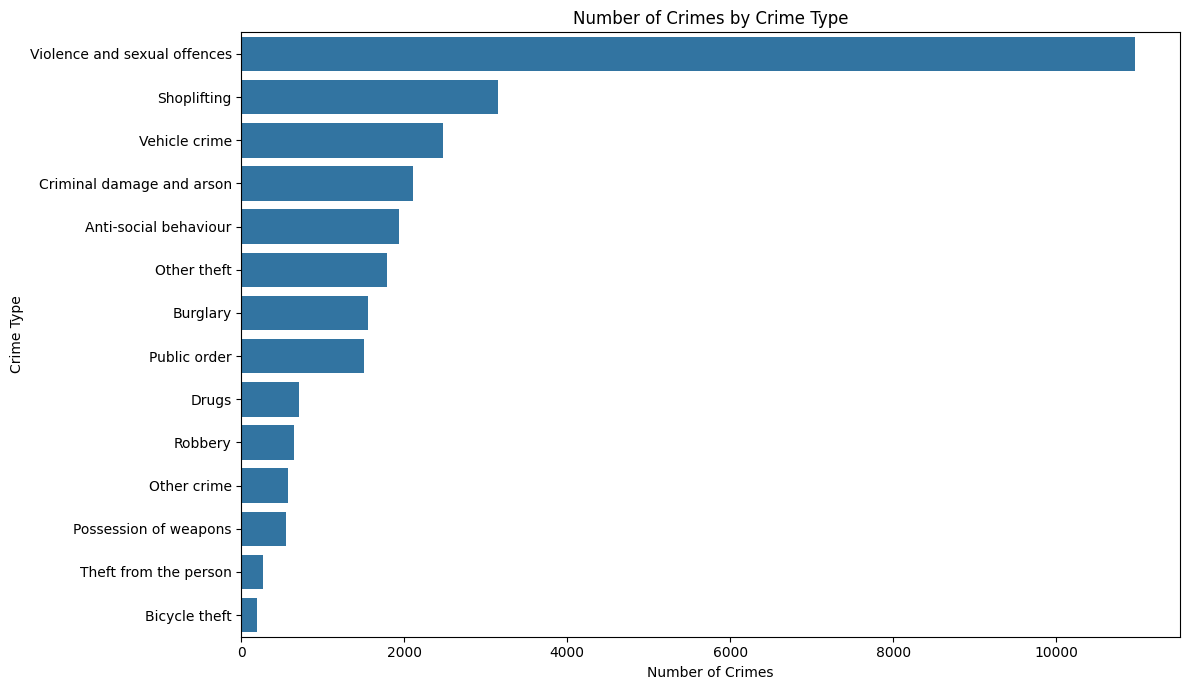

In [18]:
# Exploratory Data Analysis
#Question 1: What are the most common types of crime?
crime_counts = df["Crime_Type"].value_counts()
crime_counts
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Crime_Type",
    order=df["Crime_Type"].value_counts().index
)

plt.title("Number of Crimes by Crime Type")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

plt.tight_layout()

plt.savefig("../visuals/seaborn_crime_counts.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

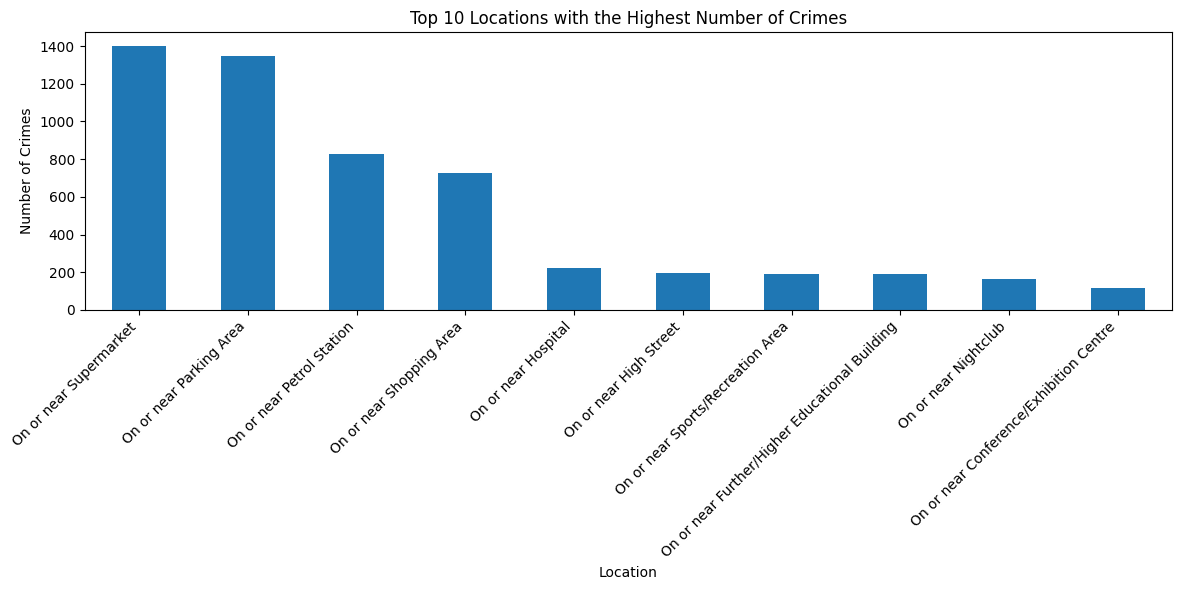

In [ ]:
# Analysis Question 2: Which locations recorded the highest number of crimes?
top_locations = df["Location"].value_counts().head(10)
top_locations
import matplotlib.pyplot as plt

top_locations.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Locations with the Highest Number of Crimes")
plt.xlabel("Location")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save the chart
plt.savefig("../visuals/top_10_locations.png", dpi=300)

plt.show()

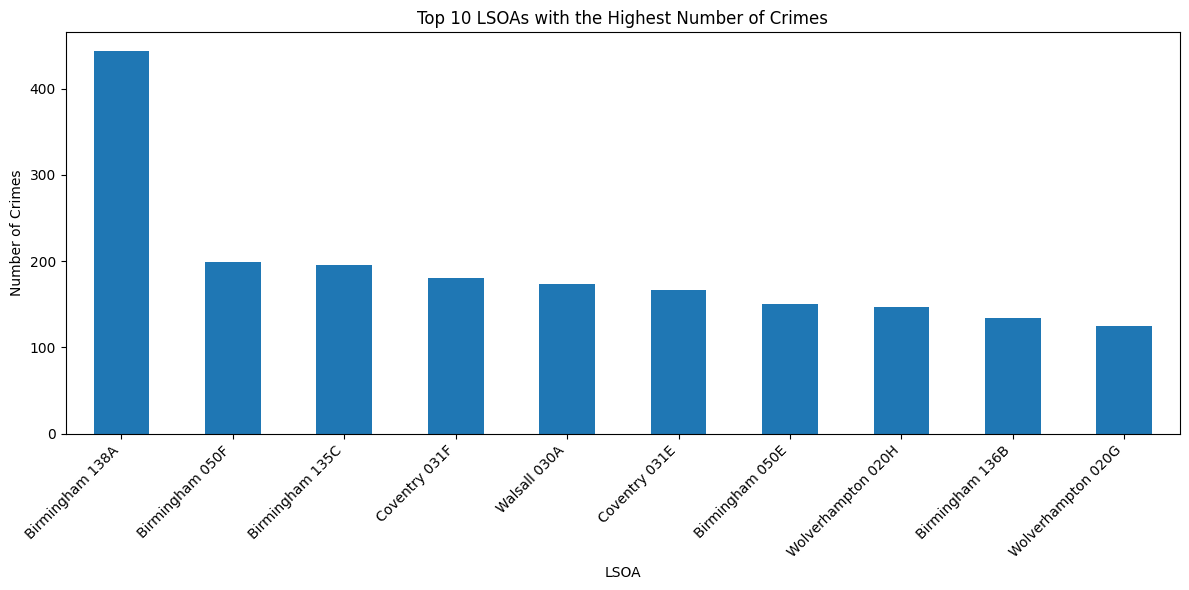

In [ ]:
# Analysis Question 3: Which LSOA (neighbourhood) experienced the highest crime rate?
top_lsoa = df["LSOA_Name"].value_counts().head(10)
top_lsoa

# Visualization
import matplotlib.pyplot as plt

top_lsoa.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 LSOAs with the Highest Number of Crimes")
plt.xlabel("LSOA")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save the chart
plt.savefig("../visuals/top_10_lsoa.png", dpi=300)

plt.show()

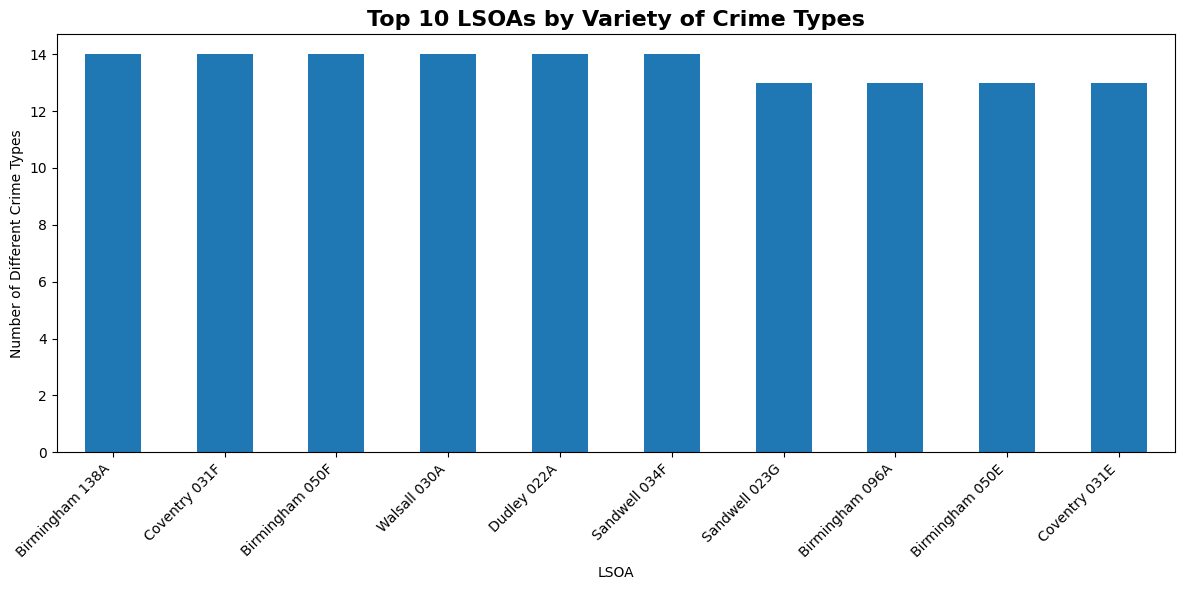

In [ ]:
# Analysis Question 4: Which LSOAs have the greatest variety of crime types?

crime_variety = df.groupby("LSOA_Name")["Crime_Type"].nunique()

top_variety = crime_variety.sort_values(ascending=False).head(10)

top_variety

# Visualization
import matplotlib.pyplot as plt

top_variety.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 LSOAs by Variety of Crime Types", fontsize=16, fontweight="bold")
plt.xlabel("LSOA")
plt.ylabel("Number of Different Crime Types")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../visuals/lsoa_crime_variety.png", dpi=300)

plt.show()

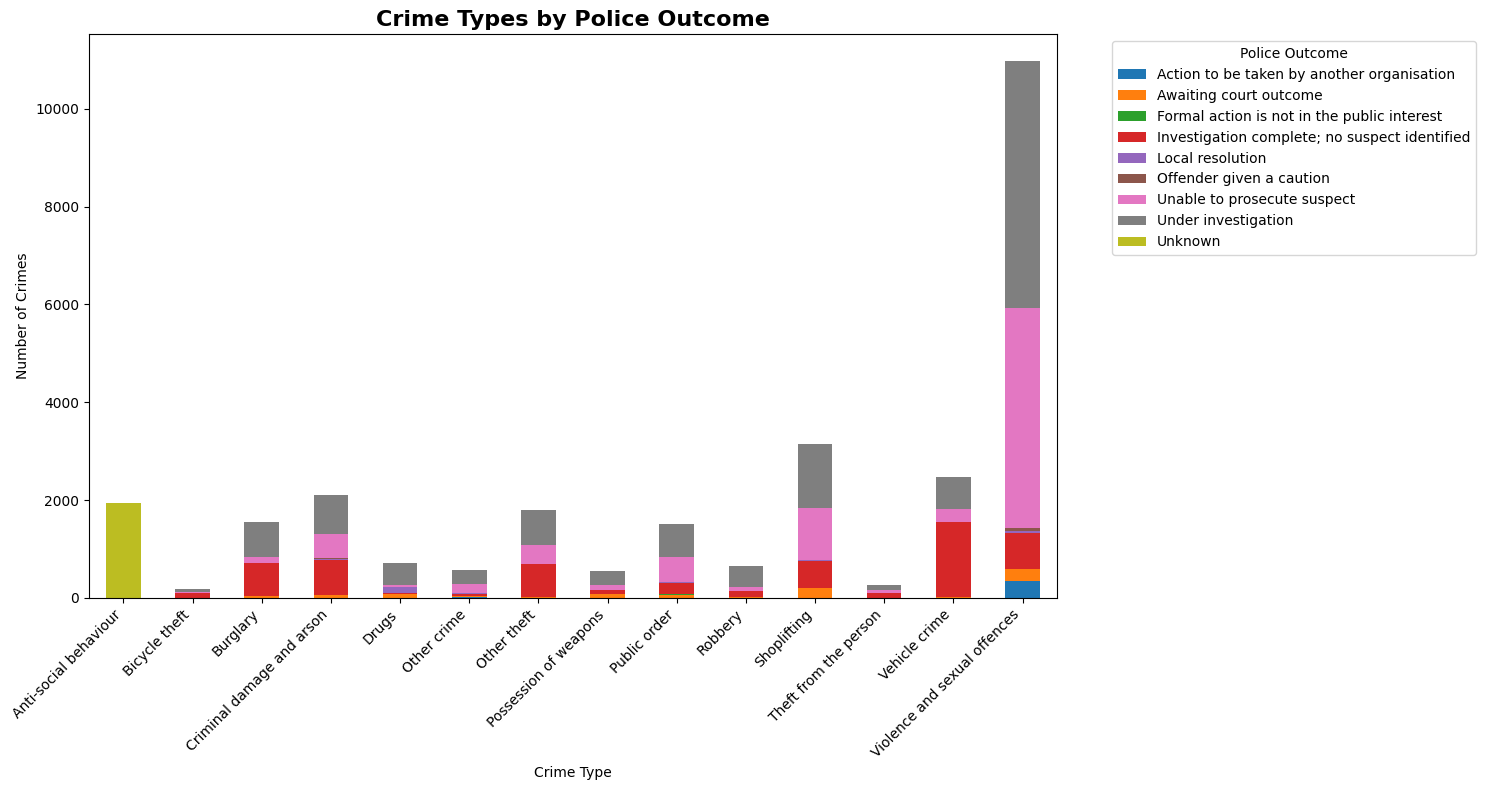

In [ ]:
# Analysis Question 5: Which crime types resulted in each police outcome?

crime_outcome = pd.crosstab(
    df["Crime_Type"],
    df["Last_Outcome_Category"]
)

crime_outcome

# Visualization
crime_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(15,8)
)

plt.title("Crime Types by Police Outcome", fontsize=16, fontweight="bold")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Police Outcome",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig("../visuals/crime_type_vs_outcome.png", dpi=300)

plt.show()

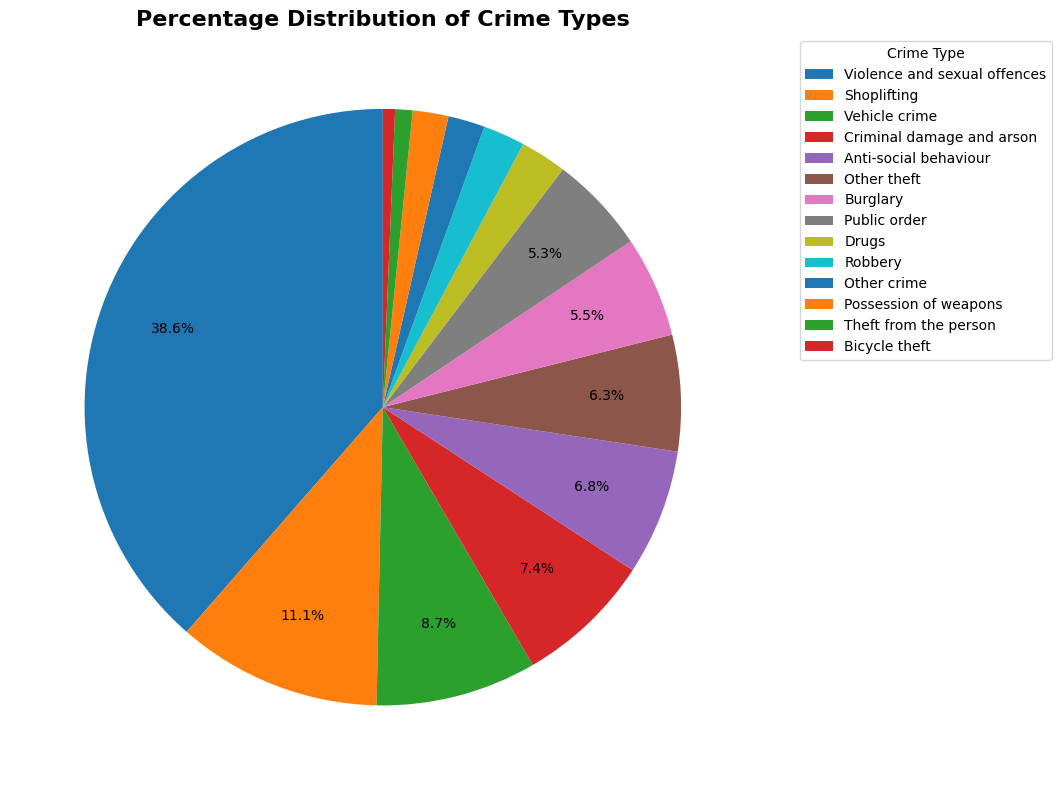

In [ ]:
# Analysis Question 6: What percentage of crimes fall into each crime category
crime_percent = df["Crime_Type"].value_counts(normalize=True) * 100

# Visualization for Analysis Question 6

import matplotlib.pyplot as plt

def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

plt.figure(figsize=(10, 8))

crime_percent.plot(
    kind="pie",
    labels=None,               
    autopct=autopct_format,    
    startangle=90,
    pctdistance=0.75
)

plt.title("Percentage Distribution of Crime Types",
          fontsize=16,
          fontweight="bold")

plt.legend(
    crime_percent.index,
    title="Crime Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylabel("")
plt.tight_layout()

plt.savefig("../visuals/crime_type_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

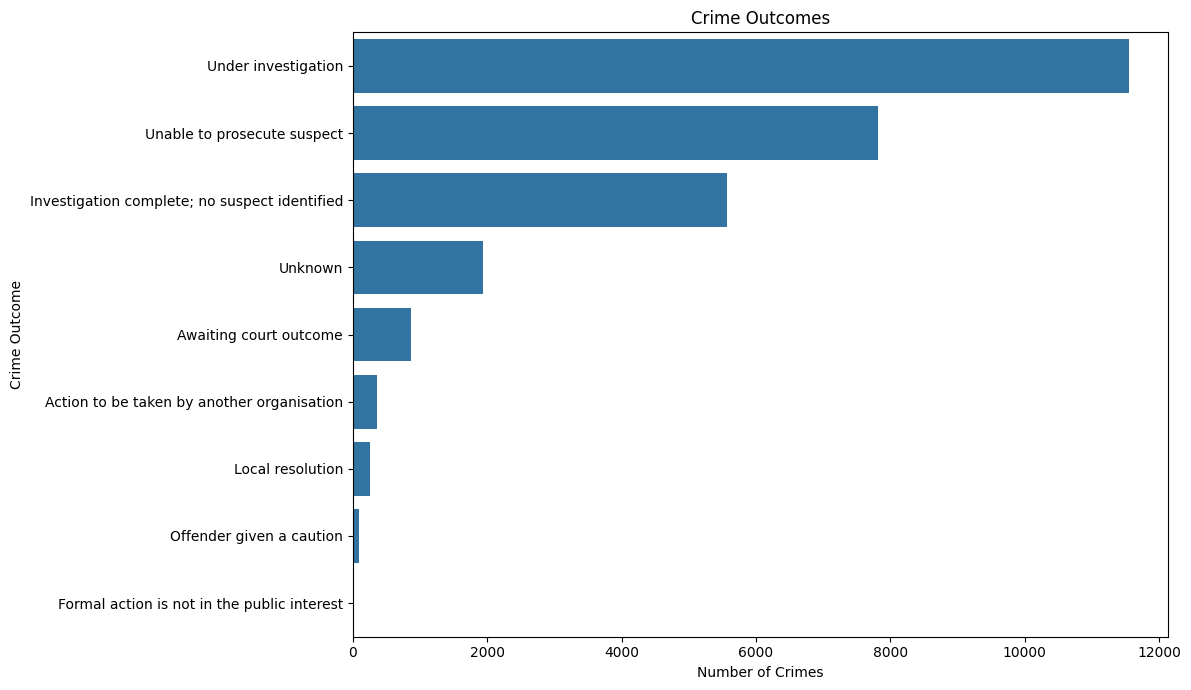

In [19]:
# Analysis Question 7: What are the most common crime outcomes?

outcomes = df["Last_Outcome_Category"].value_counts()
outcomes

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Last_Outcome_Category",
    order=df["Last_Outcome_Category"].value_counts().index
)

plt.title("Crime Outcomes")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Outcome")

plt.tight_layout()

plt.savefig("../visuals/seaborn_outcomes.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

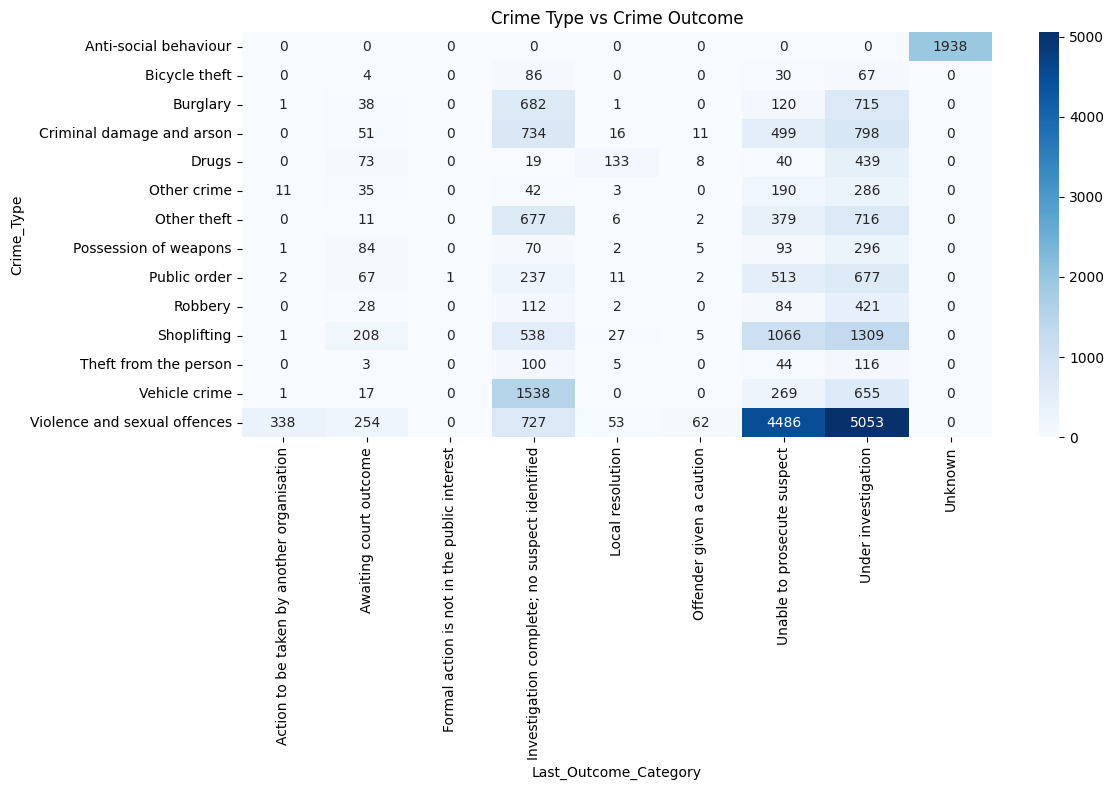

In [21]:
#Analysis Question 8: Is there a relationship between crime type and crime outcome?
pd.crosstab(df["Crime_Type"], df["Last_Outcome_Category"])

crime_outcome = pd.crosstab(
    df["Crime_Type"],
    df["Last_Outcome_Category"]
)

crime_outcome

plt.figure(figsize=(12,8))

sns.heatmap(
    crime_outcome,
    cmap="Blues",
    annot=True,
    fmt="d"
)

plt.title("Crime Type vs Crime Outcome")

plt.tight_layout()

plt.savefig("../visuals/crime_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

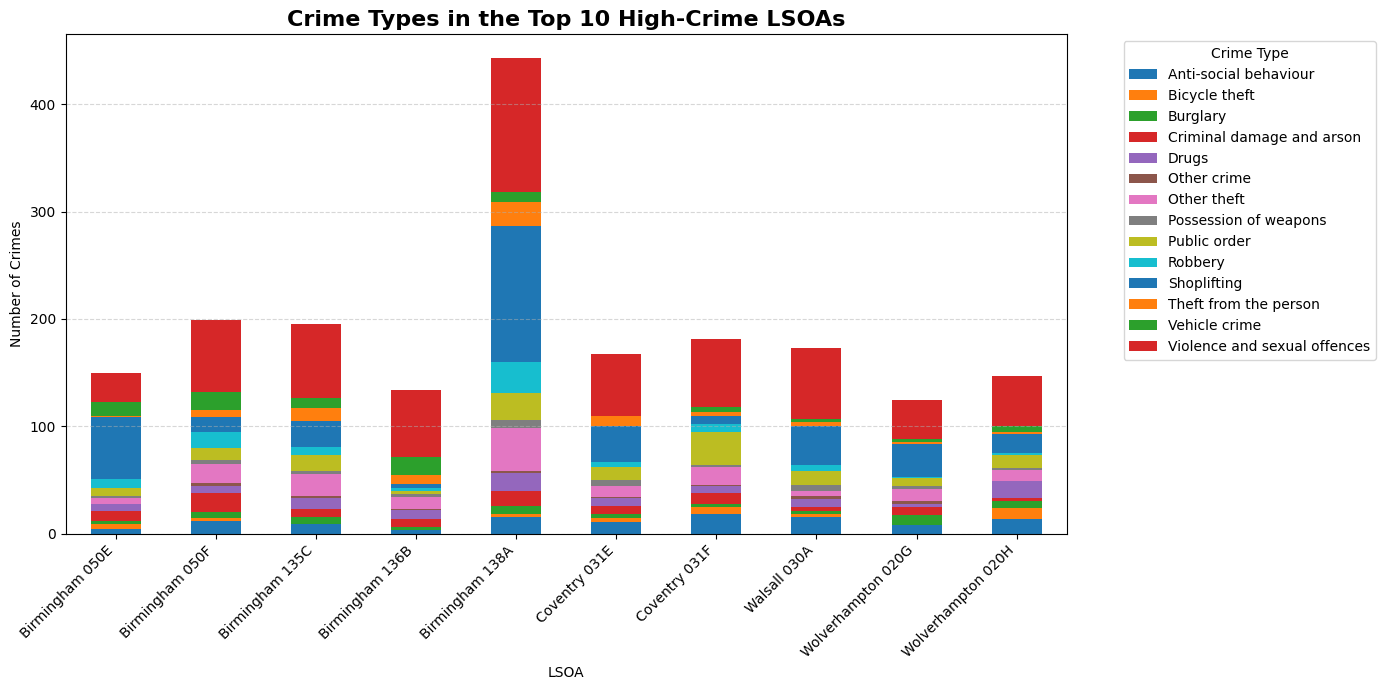

In [ ]:
# Analysis Question 9: Which crime types are most common in the top 10 high-crime neighbourhoods (LSOAs)?

# Find the top 10 LSOAs with the highest number of crimes
top_lsoa = df["LSOA_Name"].value_counts().head(10).index

# Filter the dataset to include only the top 10 LSOAs
top_lsoa_df = df[df["LSOA_Name"].isin(top_lsoa)]

# Create a cross-tabulation of LSOAs and Crime Types
crime_lsoa = pd.crosstab(
    top_lsoa_df["LSOA_Name"],
    top_lsoa_df["Crime_Type"]
)

# Display the table
crime_lsoa

# Visualization

import matplotlib.pyplot as plt

crime_lsoa.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title(
    "Crime Types in the Top 10 High-Crime LSOAs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("LSOA")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "../visuals/crime_types_top10_lsoas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

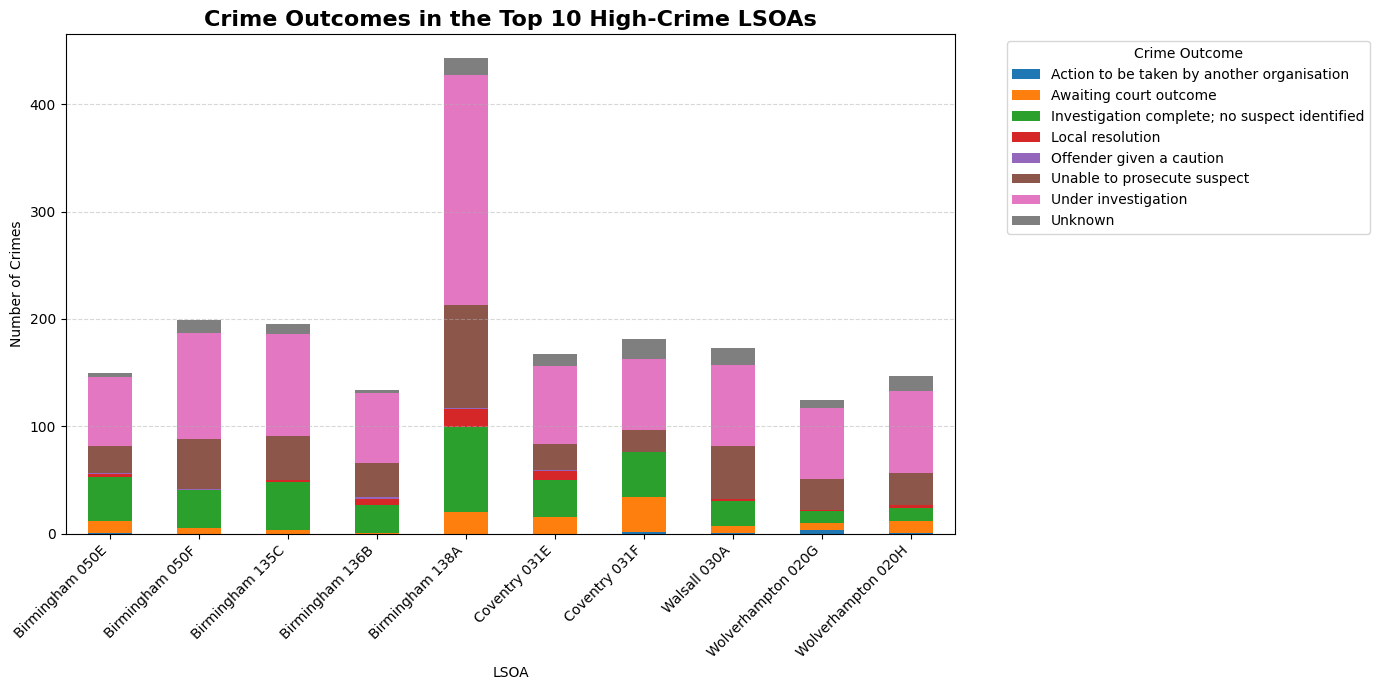

In [ ]:
# Analysis Question 13: Which crime outcomes are most common in the top 10 high-crime neighbourhoods (LSOAs)?

# Get the top 10 LSOAs
top_lsoa = df["LSOA_Name"].value_counts().head(10).index

# Filter the dataset
top_lsoa_df = df[df["LSOA_Name"].isin(top_lsoa)]

# Create a cross-tabulation
lsoa_outcomes = pd.crosstab(
    top_lsoa_df["LSOA_Name"],
    top_lsoa_df["Last_Outcome_Category"]
)

# Display the table
lsoa_outcomes

import matplotlib.pyplot as plt

lsoa_outcomes.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title(
    "Crime Outcomes in the Top 10 High-Crime LSOAs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("LSOA")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Crime Outcome",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save the visualization
plt.savefig(
    "../visuals/crime_outcomes_top10_lsoas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()